In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')
import mplhep as hep
from matplotlib import colors

import argparse
import os
import uproot
import awkward as ak
from glob import glob

from boostedhh import utils

import xgboost as xgb

# from postprocessing import load_samples

In [ ]:
# Can i have 

In [2]:
## Root Files

# year = 2023
# MC_data_json = f"data/index_{year}.json"

# with open(MC_data_json, "r") as f:
#     mc_data = json.load(f)

# # display(list(mc_data["HHbbtt"].keys()))

# sample_name = "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00"
# ggf_sm = mc_data["HHbbtt"][sample_name]

# sample_name = "VBFHHto2B2Tau_CV_1_C2V_1_C3_1"
# vbf_sm = mc_data["HHbbtt"][sample_name]

# print(len(ggf_sm))
# print(len(vbf_sm))

# file_path = ggf_sm[0]

# with uproot.open(file_path) as f:
#     print("Keys in file:", f.keys())
#     tree = f["Events"]
#     events = tree.arrays(library="ak")

# print(events)

In [3]:
SKIM_DIR = "/eos/uscms/store/user/lumori/bbtautau/skimmer"
VERSION_NAME = "25Sep23AddVars_v12_private_signal"
DATA_DIR = os.path.join(SKIM_DIR, VERSION_NAME)

YEARS = ['2022', '2022EE', '2023', '2023BPix']
SUBDIR = "parquet"

DATASET_MAP = {
    "ggF_sm" : "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00",
    "vbf_sm" : "VBFHHto2B2Tau_CV_1_C2V_1_C3_1"
}

dfs = {}

try: 
    del df_ggF_sm, df_vbf_sm
except:
    pass

for key, sample_name in DATASET_MAP.items():
    parquet_paths = []
    for year in YEARS:
        sample_path = os.path.join(DATA_DIR, year, sample_name, SUBDIR)
        if os.path.exists(sample_path):
            parquet_paths.extend(glob(os.path.join(sample_path, "*.parquet")))
        else:
            print(f"Skipped missing: {sample_path}")

    if parquet_paths:
        df = pd.concat([pd.read_parquet(pq) for pq in parquet_paths], ignore_index=True)
        dfs[key] = df
        print(f"Loaded {len(df)} rows into df_{key} from {len(parquet_paths)} files.")
    else:
        print(f"No files found for {key}, skipping.")

df_ggF_sm = dfs.get("ggF_sm")
df_vbf_sm = dfs.get("vbf_sm")

del dfs

Loaded 377608 rows into df_ggF_sm from 25 files.
Loaded 120652 rows into df_vbf_sm from 14 files.


In [4]:
# ADD BDT
MODEL_ROOT = Path("/eos/uscms/store/user/lumori/bbtautau/trained_models")
EXP_NAME = "10July25_baseline"
RUN_DIR    = (MODEL_ROOT / EXP_NAME).resolve()

assert RUN_DIR.exists(), f"Run dir not found: {RUN_DIR}"
print("RUN_DIR:", RUN_DIR)
print("FILES:", sorted([p.name for p in RUN_DIR.iterdir()]))

bst = xgb.Booster()
bst.load_model(str(RUN_DIR / "10July25_baseline.json"))

feat_names = getattr(bst, "feature_names", None)
print("Feature names:", feat_names)

def gather(df, base, taujet_idx, dtype=np.float32):
    N = len(df)
    out = np.zeros(N, dtype=dtype)
    for i in range(N):
        key = (base, int(taujet_idx[i]))
        out[i] = df[key].iloc[i] if key in df.columns else 0.0
    return out

def add_bdt_df(df):
    jet_indices = sorted({j for (name, j) in df.columns if name == 'ak8FatJetPt'})
    print("Found jet indices:", jet_indices)

    # build ττ-like jet (argmax of sum of τ-decay ParT scores)
    tau_like = []
    for j in jet_indices:
        tau_like.append(
            df[('ak8FatJetParTXtauhtauh', j)].to_numpy(np.float32, copy=False) +
            df[('ak8FatJetParTXtauhtaue', j)].to_numpy(np.float32, copy=False) +
            df[('ak8FatJetParTXtauhtaum', j)].to_numpy(np.float32, copy=False)
        )
    tau_like = np.column_stack(tau_like)
    taujet_pos = np.argmax(tau_like, axis=1)                         # position within jet_indices
    taujet_idx = np.array([jet_indices[k] for k in taujet_pos], dtype=np.int32)

    print("Tau jet indices:", taujet_idx)

    # build bb-like jet (argmax of ParT Xbb)
    xbb_mat = []
    for j in jet_indices:
        xbb_mat.append(df[('ak8FatJetParTXbb', j)].to_numpy(np.float32, copy=False))
    xbb_mat = np.column_stack(xbb_mat)
    bb_pos1 = np.argmax(xbb_mat, axis=1)
    bb_idx1 = np.array([jet_indices[k] for k in bb_pos1], dtype=np.int32)

    # If the same jet is both τ and bb, take the second-best Xbb for bb-jet (when available)
    order = np.argsort(xbb_mat, axis=1)  # ascending
    second_best_pos = order[:, -2] if xbb_mat.shape[1] >= 2 else bb_pos1
    bb_idx = bb_idx1.copy()
    same = (bb_idx1 == taujet_idx)
    bb_idx[same] = np.array([jet_indices[p] for p in second_best_pos[same]], dtype=np.int32)

    print("BB jet indices:", bb_idx)

    print("Number of events with same jet for ττ and bb:", np.sum(bb_idx == taujet_idx))

    # Add BDT scores to df
    METPt  = df[('METPt', 0)].to_numpy(np.float32, copy=False)
    METPhi = df[('METPhi', 0)].to_numpy(np.float32, copy=False)

    ttFatJetPt  = gather(df, 'ak8FatJetPt', taujet_idx)
    ttFatJetPhi = gather(df, 'ak8FatJetPhi', taujet_idx)
    ttFatJetEta = gather(df, 'ak8FatJetEta', taujet_idx)

    # ParT masses
    tt_mRes = gather(df, 'ak8FatJetParTmassResApplied', taujet_idx)
    tt_mVis = gather(df, 'ak8FatJetParTmassVisApplied', taujet_idx)

    # QCD / Top components
    qcd0  = gather(df, 'ak8FatJetParTQCD0HF', taujet_idx)
    qcd1  = gather(df, 'ak8FatJetParTQCD1HF', taujet_idx)
    qcd2  = gather(df, 'ak8FatJetParTQCD2HF', taujet_idx)
    topW  = gather(df, 'ak8FatJetParTTopW', taujet_idx)
    topbW = gather(df, 'ak8FatJetParTTopbW', taujet_idx)

    # Sums required by the model
    tt_qcd = (qcd0 + qcd1 + qcd2).astype(np.float32)
    tt_top = (topW + topbW).astype(np.float32)

    # ττ and Xbb ParT outputs
    tx_hh  = gather(df, 'ak8FatJetParTXtauhtauh', taujet_idx)
    tx_he  = gather(df, 'ak8FatJetParTXtauhtaue', taujet_idx)
    tx_hm  = gather(df, 'ak8FatJetParTXtauhtaum', taujet_idx)
    tx_xbb = gather(df, 'ak8FatJetParTXbb', taujet_idx)

    df_bdt = pd.DataFrame({
        'METPt': METPt,
        'METPhi': METPhi,
        'ttFatJetPt': ttFatJetPt,
        'ttFatJetPhi': ttFatJetPhi,
        'ttFatJetEta': ttFatJetEta,
        'ttFatJetParTmassResApplied': tt_mRes,
        'ttFatJetParTmassVisApplied': tt_mVis,
        'ttFatJetParTQCD': tt_qcd,
        'ttFatJetParTTop': tt_top,
        'ttFatJetParTQCD0HF': qcd0,
        'ttFatJetParTQCD1HF': qcd1,
        'ttFatJetParTQCD2HF': qcd2,
        'ttFatJetParTTopW': topW,
        'ttFatJetParTTopbW': topbW,
        'ttFatJetParTXtauhtauh': tx_hh,
        'ttFatJetParTXtauhtaue': tx_he,
        'ttFatJetParTXtauhtaum': tx_hm,
        'ttFatJetParTXbb': tx_xbb,
    }, columns=feat_names).astype(np.float32)

    print("df_bdt.shape:", df_bdt.shape)

    yhat = bst.inplace_predict(df_bdt)
    print(yhat.shape)

    # yhat is (nEvents, nClasses)
    n_classes = yhat.shape[1]

    for cls_idx in range(n_classes):
        df[("bdt_score", cls_idx)] = yhat[:, cls_idx].astype(np.float32)

    df[("bdt_best_score", 0)] = np.max(yhat, axis=1).astype(np.float32)
    df[("bdt_best_class", 0)] = np.argmax(yhat, axis=1).astype(np.int32)
    
    return df


df_ggF_sm = add_bdt_df(df_ggF_sm)
df_vbf_sm = add_bdt_df(df_vbf_sm)

RUN_DIR: /eos/uscms/store/user/lmori/bbtautau/trained_models/10July25_baseline
FILES: ['10July25_baseline.json', 'dtrain.buffer', 'dtrain_rescaled.buffer', 'dval.buffer', 'dval_rescaled.buffer', 'evals_result.json', 'feature_importance_gain.pdf', 'feature_importance_gain.png', 'feature_importance_total_gain.pdf', 'feature_importance_total_gain.png', 'feature_importance_weight.pdf', 'feature_importance_weight.png', 'outputs', 'rocs', 'scores', 'training_history.pdf', 'training_history.png', 'weight_stats.csv']


Feature names: ['METPt', 'METPhi', 'ttFatJetPt', 'ttFatJetPhi', 'ttFatJetEta', 'ttFatJetParTmassResApplied', 'ttFatJetParTmassVisApplied', 'ttFatJetParTQCD', 'ttFatJetParTTop', 'ttFatJetParTQCD0HF', 'ttFatJetParTQCD1HF', 'ttFatJetParTQCD2HF', 'ttFatJetParTTopW', 'ttFatJetParTTopbW', 'ttFatJetParTXtauhtauh', 'ttFatJetParTXtauhtaue', 'ttFatJetParTXtauhtaum', 'ttFatJetParTXbb']
Found jet indices: [0, 1, 2]
Tau jet indices: [1 0 0 ... 0 1 0]
BB jet indices: [0 2 1 ... 2 0 2]
Number of events with same jet for ττ and bb: 0
df_bdt.shape: (377608, 18)
(377608, 8)
Found jet indices: [0, 1, 2]
Tau jet indices: [0 0 0 ... 0 1 0]
BB jet indices: [1 2 1 ... 2 0 2]
Number of events with same jet for ττ and bb: 0
df_bdt.shape: (120652, 18)
(120652, 8)


In [5]:
for cols in df.columns:
    print(cols)

('GenHiggsEta', 0)
('GenHiggsEta', 1)
('GenHiggsPhi', 0)
('GenHiggsPhi', 1)
('GenHiggsMass', 0)
('GenHiggsMass', 1)
('GenHiggsPt', 0)
('GenHiggsPt', 1)
('GenHiggsChildren', 0)
('GenHiggsChildren', 1)
('GenbbEta', 0)
('GenbbEta', 1)
('GenbbPhi', 0)
('GenbbPhi', 1)
('GenbbMass', 0)
('GenbbMass', 1)
('GenbbPt', 0)
('GenbbPt', 1)
('GenTauEta', 0)
('GenTauEta', 1)
('GenTauPhi', 0)
('GenTauPhi', 1)
('GenTauMass', 0)
('GenTauMass', 1)
('GenTauPt', 0)
('GenTauPt', 1)
('GenTauhh', 0)
('GenTauhm', 0)
('GenTauhe', 0)
('run', 0)
('event', 0)
('luminosityBlock', 0)
('ht', 0)
('nElectrons', 0)
('nMuons', 0)
('nTaus', 0)
('nBoostedTaus', 0)
('nJets', 0)
('nFatJets', 0)
('nSubJets', 0)
('nPU', 0)
('nPV', 0)
('ElectronTrigMatchEGamma', 0)
('ElectronTrigMatchEGamma', 1)
('ElectronTrigMatchETau', 0)
('ElectronTrigMatchETau', 1)
('MuonTrigMatchMuon', 0)
('MuonTrigMatchMuon', 1)
('MuonTrigMatchMuonTau', 0)
('MuonTrigMatchMuonTau', 1)
('TauTrigMatchSingleTau', 0)
('TauTrigMatchSingleTau', 1)
('TauTrigMatchD

In [6]:
# ADD BDT (Optimized speed and memory)
# def _get_col(df, base, j, N):
#     # CHANGE: Fast accessor returning a float32 NumPy view or zeros if missing
#     # REASON: Avoid try/except and repeated `.iloc`; keeps types consistent.
#     col = (base, j)
#     if col in df.columns:
#         return df[col].to_numpy(np.float32, copy=False)
#     return np.zeros(N, dtype=np.float32)

# def add_bdt_df(df, *, chunk_rows=None, set_nthread=True):
#     N = len(df)
#     if N == 0:
#         return df

#     # CHANGE: Let XGBoost use all cores (optional, safe on shared nodes if you tune externally)
#     # REASON: Shift bottleneck to compute throughput, not Python overhead.
#     if set_nthread:
#         try:
#             bst.set_param({"nthread": os.cpu_count()})
#         except Exception:
#             pass

#     # ---- Discover AK8 jet slots once ----
#     jet_indices = sorted({j for (name, j) in df.columns if name == 'ak8FatJetPt'})
#     J = len(jet_indices)
#     assert J >= 1, "No AK8 jets found."

#     # =========================
#     # Pass 1: pick tau-jet (argmax τ-like) and bb-jet (top-1/2 Xbb)
#     # =========================
#     neg_inf = np.full(N, -np.inf, dtype=np.float32)

#     # τ-like argmax
#     tau_best = neg_inf.copy()
#     tau_pos  = np.zeros(N, dtype=np.int32)   # position in 0..J-1

#     # Xbb top-1 & top-2 trackers
#     xbb_top1 = neg_inf.copy()
#     xbb_pos1 = np.zeros(N, dtype=np.int32)
#     xbb_top2 = neg_inf.copy()
#     xbb_pos2 = np.zeros(N, dtype=np.int32)

#     for pos, j in enumerate(jet_indices):
#         hh = _get_col(df, 'ak8FatJetParTXtauhtauh', j, N)
#         he = _get_col(df, 'ak8FatJetParTXtauhtaue', j, N)
#         hm = _get_col(df, 'ak8FatJetParTXtauhtaum', j, N)
#         s_tau = hh + he + hm

#         better_tau = s_tau > tau_best
#         if better_tau.any():
#             tau_best[better_tau] = s_tau[better_tau]
#             tau_pos[better_tau]  = pos

#         xbb = _get_col(df, 'ak8FatJetParTXbb', j, N)

#         better1 = xbb > xbb_top1
#         if better1.any():
#             # promote current top1 to top2 where improved
#             xbb_top2[better1] = xbb_top1[better1]
#             xbb_pos2[better1] = xbb_pos1[better1]
#             # set new top1
#             xbb_top1[better1] = xbb[better1]
#             xbb_pos1[better1] = pos

#         not_better = ~better1
#         if not_better.any():
#             cand = xbb[not_better]
#             better2 = cand > xbb_top2[not_better]
#             if better2.any():
#                 idx = np.flatnonzero(not_better)[better2]
#                 xbb_top2[idx] = xbb[idx]
#                 xbb_pos2[idx] = pos

#     # Resolve bb position; fall back to top1 if only one jet
#     bb_pos = xbb_pos1.copy()
#     collide = bb_pos == tau_pos
#     if collide.any():
#         if J >= 2:
#             bb_pos[collide] = xbb_pos2[collide]
#         # else J==1: keep top1 (identical)

#     # =========================
#     # Pass 2: gather τ-jet features in a single masked pass
#     # =========================
#     ttFatJetPt   = np.zeros(N, dtype=np.float32)
#     ttFatJetPhi  = np.zeros(N, dtype=np.float32)
#     ttFatJetEta  = np.zeros(N, dtype=np.float32)
#     tt_mRes      = np.zeros(N, dtype=np.float32)
#     tt_mVis      = np.zeros(N, dtype=np.float32)
#     qcd0         = np.zeros(N, dtype=np.float32)
#     qcd1         = np.zeros(N, dtype=np.float32)
#     qcd2         = np.zeros(N, dtype=np.float32)
#     topW         = np.zeros(N, dtype=np.float32)
#     topbW        = np.zeros(N, dtype=np.float32)
#     tx_hh        = np.zeros(N, dtype=np.float32)
#     tx_he        = np.zeros(N, dtype=np.float32)
#     tx_hm        = np.zeros(N, dtype=np.float32)
#     tx_xbb_tau   = np.zeros(N, dtype=np.float32)  # Xbb evaluated on tau-jet

#     for pos, j in enumerate(jet_indices):
#         m = (tau_pos == pos)
#         if not m.any():
#             continue
#         np.copyto(ttFatJetPt[m],   _get_col(df, 'ak8FatJetPt',                   j, N)[m])
#         np.copyto(ttFatJetPhi[m],  _get_col(df, 'ak8FatJetPhi',                  j, N)[m])
#         np.copyto(ttFatJetEta[m],  _get_col(df, 'ak8FatJetEta',                  j, N)[m])
#         np.copyto(tt_mRes[m],      _get_col(df, 'ak8FatJetParTmassResApplied',   j, N)[m])
#         np.copyto(tt_mVis[m],      _get_col(df, 'ak8FatJetParTmassVisApplied',   j, N)[m])
#         np.copyto(qcd0[m],         _get_col(df, 'ak8FatJetParTQCD0HF',           j, N)[m])
#         np.copyto(qcd1[m],         _get_col(df, 'ak8FatJetParTQCD1HF',           j, N)[m])
#         np.copyto(qcd2[m],         _get_col(df, 'ak8FatJetParTQCD2HF',           j, N)[m])
#         np.copyto(topW[m],         _get_col(df, 'ak8FatJetParTTopW',             j, N)[m])
#         np.copyto(topbW[m],        _get_col(df, 'ak8FatJetParTTopbW',            j, N)[m])
#         np.copyto(tx_hh[m],        _get_col(df, 'ak8FatJetParTXtauhtauh',        j, N)[m])
#         np.copyto(tx_he[m],        _get_col(df, 'ak8FatJetParTXtauhtaue',        j, N)[m])
#         np.copyto(tx_hm[m],        _get_col(df, 'ak8FatJetParTXtauhtaum',        j, N)[m])
#         np.copyto(tx_xbb_tau[m],   _get_col(df, 'ak8FatJetParTXbb',              j, N)[m])

#     tt_qcd = (qcd0 + qcd1 + qcd2).astype(np.float32, copy=False)
#     tt_top = (topW + topbW).astype(np.float32, copy=False)

#     METPt  = df[('METPt', 0)].to_numpy(np.float32, copy=False)
#     METPhi = df[('METPhi', 0)].to_numpy(np.float32, copy=False)

#     # =========================
#     # Feature assembly in model order (no pandas overhead)
#     # =========================
#     required = [
#         'METPt',
#         'METPhi',
#         'ttFatJetPt',
#         'ttFatJetPhi',
#         'ttFatJetEta',
#         'ttFatJetParTmassResApplied',
#         'ttFatJetParTmassVisApplied',
#         'ttFatJetParTQCD',
#         'ttFatJetParTTop',
#         'ttFatJetParTQCD0HF',
#         'ttFatJetParTQCD1HF',
#         'ttFatJetParTQCD2HF',
#         'ttFatJetParTTopW',
#         'ttFatJetParTTopbW',
#         'ttFatJetParTXtauhtauh',
#         'ttFatJetParTXtauhtaue',
#         'ttFatJetParTXtauhtaum',
#         'ttFatJetParTXbb',
#     ]
#     feat_map = {
#         'METPt': METPt,
#         'METPhi': METPhi,
#         'ttFatJetPt': ttFatJetPt,
#         'ttFatJetPhi': ttFatJetPhi,
#         'ttFatJetEta': ttFatJetEta,
#         'ttFatJetParTmassResApplied': tt_mRes,
#         'ttFatJetParTmassVisApplied': tt_mVis,
#         'ttFatJetParTQCD': tt_qcd,
#         'ttFatJetParTTop': tt_top,
#         'ttFatJetParTQCD0HF': qcd0,
#         'ttFatJetParTQCD1HF': qcd1,
#         'ttFatJetParTQCD2HF': qcd2,
#         'ttFatJetParTTopW': topW,
#         'ttFatJetParTTopbW': topbW,
#         'ttFatJetParTXtauhtauh': tx_hh,
#         'ttFatJetParTXtauhtaue': tx_he,
#         'ttFatJetParTXtauhtaum': tx_hm,
#         'ttFatJetParTXbb': tx_xbb_tau,
#     }
#     _feat_names = getattr(bst, "feature_names", None)
#     order = _feat_names if _feat_names else required

#     # =========================
#     # Predict (optionally chunked) and attach outputs
#     # =========================
#     def _predict_and_attach(X_block, start_idx):
#         yhat = bst.inplace_predict(X_block)
#         if yhat.ndim == 1:  # binary objectives
#             yhat = np.column_stack([1.0 - yhat, yhat]).astype(np.float32, copy=False)
#         C = yhat.shape[1]
#         # write-back (avoid per-row ops)
#         for c in range(C):
#             df[('bdt_score', c)].iloc[start_idx:start_idx+len(X_block)] = yhat[:, c]
#         df[('bdt_best_score', 0)].iloc[start_idx:start_idx+len(X_block)] = yhat.max(axis=1)
#         df[('bdt_best_class', 0)].iloc[start_idx:start_idx+len(X_block)] = yhat.argmax(axis=1)

#     # Pre-create output columns to enable vectorized slice assignments
#     df[('bdt_score', 0)] = np.zeros(N, dtype=np.float32)  # will be resized if C>2 below
#     df[('bdt_best_score', 0)] = np.zeros(N, dtype=np.float32)
#     df[('bdt_best_class', 0)] = np.zeros(N, dtype=np.int32)

#     # Build the full feature matrix lazily in chunks to minimize peak RAM
#     F = len(order)
#     if chunk_rows is None or chunk_rows >= N:
#         X = np.column_stack([np.asarray(feat_map.get(k, np.zeros(N, np.float32)),
#                                         dtype=np.float32) for k in order])
#         _predict_and_attach(X, 0)
#     else:
#         bs = int(chunk_rows)
#         for s in range(0, N, bs):
#             e = min(s + bs, N)
#             Xb = np.column_stack([np.asarray(feat_map.get(k, np.zeros(N, np.float32))[s:e],
#                                              dtype=np.float32) for k in order])
#             _predict_and_attach(Xb, s)

#     return df


# # Optional: tune chunk size if memory is tight; otherwise omit.
# df_ggF_sm = add_bdt_df(df_ggF_sm, chunk_rows=250_000)
# df_vbf_sm = add_bdt_df(df_vbf_sm, chunk_rows=250_000)



In [7]:
# ---------- VARIABLES TO LOOK AT FIRST ----------
# GEN sanity (HH → bb ττ)
gen_core = [
    ('GenHiggsMass', 0), ('GenHiggsMass', 1),
    ('GenHiggsPt', 0),   ('GenHiggsPt', 1),
    ('GenbbMass', 0),    ('GenbbPt', 0),
    ('GenTauPt', 0),     ('GenTauPt', 1),
    ('GenTauEta', 0),    ('GenTauEta', 1),
    ('GenTauhh', 0), ('GenTauhm', 0), ('GenTauhe', 0),
]

# RECO jets / b-tag (resolved)
reco_bb = [
    ('ak4JetPt', 0), ('ak4JetEta', 0), ('ak4JetbtagPNetB', 0),
    ('ak4JetPt', 1), ('ak4JetEta', 1), ('ak4JetbtagPNetB', 1),
    ('ak4JetPt', 2), ('ak4JetEta', 2), ('ak4JetbtagPNetB', 2),
]

# RECO τ (hadronic or leptonic as applicable)
reco_tau = [
    ('TauPt', 0), ('TauEta', 0), ('TauDeepTauvsJet', 0),
    ('TauPt', 1), ('TauEta', 1), ('TauDeepTauvsJet', 1),
]

# Boosted regime (AK8)
ak8_core = [
    ('ak8FatJetPt', 0), ('ak8FatJetMsd', 0), ('ak8FatJetPNetXbbvsQCDLegacy', 0),
    ('ak8FatJetPt', 1), ('ak8FatJetMsd', 1), ('ak8FatJetPNetXbbvsQCDLegacy', 1),
]

# VBF handles (if relevant)
vbf_core = [
    ('VBFJetPt', 0), ('VBFJetEta', 0),
    ('VBFJetPt', 1), ('VBFJetEta', 1),
]

# Event-level
event_core = [
    ('METPt', 0), ('ht', 0),
    ('nJets', 0), ('nFatJets', 0), ('nTaus', 0), ('nMuons', 0), ('nElectrons', 0),
]


In [8]:
# Histogramming
def _sanitize(x, w):
    x = np.asarray(x)
    w = np.asarray(w) if w is not None else np.ones_like(x, dtype=float)
    m = np.isfinite(x) & np.isfinite(w)
    return x[m].astype(float), w[m].astype(float)

def _make_edges(x_s, x_b, bins=50, xlim=None):
    if xlim is not None:
        xmin, xmax = float(xlim[0]), float(xlim[1])
        edges = np.linspace(xmin, xmax, int(bins)+1) if np.isscalar(bins) else np.asarray(bins, dtype=float)
        if edges[0] != xmin or edges[-1] != xmax or edges.ndim != 1:
            edges = np.linspace(xmin, xmax, int(bins)+1)
        return edges
    # automatic from data if no xlim
    data = x_s if x_b.size == 0 else (x_b if x_s.size == 0 else np.concatenate([x_s, x_b]))
    if data.size == 0:
        raise ValueError("No finite data.")
    return np.histogram_bin_edges(data, bins=int(bins) if np.isscalar(bins) else bins)

def _hist_pdf(x, w, edges):
    # counts per bin and density (pdf)
    C = np.histogram(x, bins=edges, weights=w)[0].astype(float)
    widths = np.diff(edges)
    W = w.sum()
    if W <= 0:
        # avoid divide-by-zero; return zeros
        return C, np.zeros_like(C), widths
    pdf = C / (W * widths)
    return C, pdf, widths

def tmva_separation(pdf_s, pdf_b, widths, eps=1e-15):
    # 0.5 * \int (s-b)^2/(s+b) dx:  binwise Riemann sum
    s, b = pdf_s, pdf_b
    denom = s + b
    m = denom > eps
    return float(0.5 * np.sum(((s[m] - b[m])**2 / denom[m]) * widths[m]))

def js_divergence(pdf_s, pdf_b, widths, base=2, eps=1e-15):
    # Convert densities to discrete probabilities per bin, then JSD = 0.5 KL(P||M) + 0.5 KL(Q||M)
    P = pdf_s * widths
    Q = pdf_b * widths
    P = P / max(P.sum(), eps)
    Q = Q / max(Q.sum(), eps)
    M = 0.5*(P+Q)
    def _kl(A, B):
        m = (A > 0) & (B > 0)
        return np.sum(A[m] * np.log(A[m]/B[m]))
    js = 0.5*_kl(P, M) + 0.5*_kl(Q, M)
    if base == 2:
        js = js / np.log(2.0)  # bits
    return float(js)

def _ecdf(x, w):
    if x.size == 0:
        return np.array([0.0]), np.array([0.0])
    idx = np.argsort(x)
    xs = x[idx]
    cw = np.cumsum(w[idx])
    cw = cw / cw[-1]
    return xs, cw

def _cdf_at(grid, xs, cw):
    # right-continuous step
    idx = np.searchsorted(xs, grid, side='right') - 1
    out = np.zeros_like(grid, dtype=float)
    m = idx >= 0
    out[m] = cw[idx[m]]
    return out

def ks_weighted(x_s, w_s, x_b, w_b):
    if w_s.sum() <= 0 or w_b.sum() <= 0:
        return float('nan')
    xs, cws = _ecdf(x_s, w_s)
    xb, cwb = _ecdf(x_b, w_b)
    grid = np.unique(np.concatenate([xs, xb]))
    ks = np.max(np.abs(_cdf_at(grid, xs, cws) - _cdf_at(grid, xb, cwb)))
    return float(ks)

def auc_weighted(x_s, w_s, x_b, w_b):
    # Mann–Whitney style with weights: P(X_s > X_b) + 0.5 P(=)
    Ws, Wb = w_s.sum(), w_b.sum()
    if Ws <= 0 or Wb <= 0:
        return float('nan')
    idxb = np.argsort(x_b)
    xb = x_b[idxb]; wb = w_b[idxb]
    cwb = np.cumsum(wb)
    left = np.searchsorted(xb, x_s, side='left')
    right = np.searchsorted(xb, x_s, side='right')
    wB_less  = np.where(left  > 0, cwb[left - 1], 0.0)
    wB_leq   = np.where(right > 0, cwb[right - 1], 0.0)
    wB_equal = wB_leq - wB_less
    U = np.sum(w_s * (wB_less + 0.5 * wB_equal))
    return float(U / (Ws * Wb))

def plot_with_metrics(
    dfS, dfB, variable, weight_col=('weight', 0),
    colorS='C0', colorB='C1',
    cuts=None,
    bins=50, xlim=None, ylim=None, density=False,
    labelS="Signal", labelB="Background",
    xlabel=None, title=None, alpha=0.35, logy=False,
    add_flows=True
):
    # data
    if cuts == None: 
        xS, wS = _sanitize(dfS[variable], dfS[weight_col])
        xB, wB = _sanitize(dfB[variable], dfB[weight_col])
    else: 
        assert len(cuts) == 2
        maskS =  (dfS[variable] > cuts[0]) & (dfS[variable] < cuts[1])
        maskB =  (dfB[variable] > cuts[0]) & (dfB[variable] < cuts[1])
        
        xS, wS = _sanitize(dfS[variable][maskS], dfS[weight_col][maskS])
        xB, wB = _sanitize(dfB[variable][maskB], dfB[weight_col][maskB])
        

    # edges
    edges = _make_edges(xS, xB, bins=bins, xlim=xlim)

    # base histograms
    cS, pdfS, widths = _hist_pdf(xS, wS, edges)
    cB, pdfB, _      = _hist_pdf(xB, wB, edges)

    # fold under/overflow into edge bins if a visible window is enforced
    if xlim is not None and add_flows:
        xmin, xmax = edges[0], edges[-1]
        # S
        uS = wS[xS < xmin].sum(); oS = wS[xS > xmax].sum()
        cS[0]  += uS; cS[-1] += oS
        # B
        uB = wB[xB < xmin].sum(); oB = wB[xB > xmax].sum()
        cB[0]  += uB; cB[-1] += oB
        # recompute pdf after flows (for density-based metrics)
        pdfS = cS / (max(wS.sum(), 1e-15) * widths)
        pdfB = cB / (max(wB.sum(), 1e-15) * widths)

    # metrics
    sep = tmva_separation(pdfS, pdfB, widths)
    jsd = js_divergence(pdfS, pdfB, widths, base=2)
    ks  = ks_weighted(xS, wS, xB, wB)
    auc = auc_weighted(xS, wS, xB, wB)
    
    # plot
    fig, ax = plt.subplots(figsize=(12, 6))
    # draw step + fill
    def _draw(y, W, label, color):
        y_plot = y/(W*widths) if density else y  # show density if requested
        ax.step(edges, np.r_[y_plot, y_plot[-1]], where='post', lw=1.6, label=label, color=color)
        ax.fill_between(edges, np.r_[y_plot, y_plot[-1]], step='post', alpha=alpha, color=color)

    _draw(cS, wS.sum(), labelS, colorS)
    _draw(cB, wB.sum(), labelB, colorB)

    ax.set_xlim((edges[0], edges[-1]) if xlim is None else xlim)
    if ylim is not None: ax.set_ylim(ylim)
    if logy: ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(frameon=False)
    if xlabel is None: xlabel = str(variable)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density" if density else "Weighted yield")
    ax.set_title(title if title else f"{labelS} vs {labelB}: {variable}")

    # annotate metrics
    lines = [
        f"Variable name:  {variable}",
        f"TMVA separation: {sep:.4f}",
        f"JSD (bits):      {jsd:.4f}",
        f"KS (weighted):   {ks:.4f}",
        f"AUC (weighted):  {auc:.4f}",
    ]

    # ax.text(1.02, 0.98, "\n".join(lines), transform=ax.transAxes,
    #         va='top', ha='left', fontsize=10,
    #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, lw=0.0))

    # plt.tight_layout()
    fig.subplots_adjust(right=0.75)
    plt.show()

    # also print to console (useful in logs)
    print("\n".join(lines))



In [9]:
 df["bdt_score"]

,0,1,2,3,4,5,6,7
0,0.065094,0.129231,0.052724,0.002999,0.723865,0.014532,0.002734,0.008822
1,0.030191,0.088682,0.030031,0.001939,0.811420,0.027338,0.001769,0.008630
2,0.031307,0.040187,0.020921,0.001713,0.886720,0.013315,0.001562,0.004277
3,0.969209,0.016568,0.004141,0.004066,0.001688,0.001167,0.001612,0.001550
4,0.007161,0.012228,0.006092,0.000823,0.963116,0.006883,0.000750,0.002946
...,...,...,...,...,...,...,...,...
120647,0.093710,0.380763,0.117745,0.004505,0.373731,0.014190,0.004107,0.011249
120648,0.052565,0.094752,0.061988,0.003088,0.746182,0.030444,0.002816,0.008165
120649,0.314173,0.195526,0.350675,0.004808,0.099895,0.014731,0.004386,0.015805
120650,0.314066,0.497241,0.169405,0.002780,0.005229,0.003529,0.002536,0.005214


In [10]:
%matplotlib inline
plt.style.use('default')

plt.rcParams.update({
    "font.size": 16,           # Global font size
    "axes.titlesize": 16,      # Title font size
    "axes.labelsize": 16,      # Axis label font size
    "xtick.labelsize": 16,     # X tick label font size
    "ytick.labelsize": 16,     # Y tick label font size
    "legend.fontsize": 16,     # Legend font size
    "figure.titlesize": 16,    # Figure title font size
})

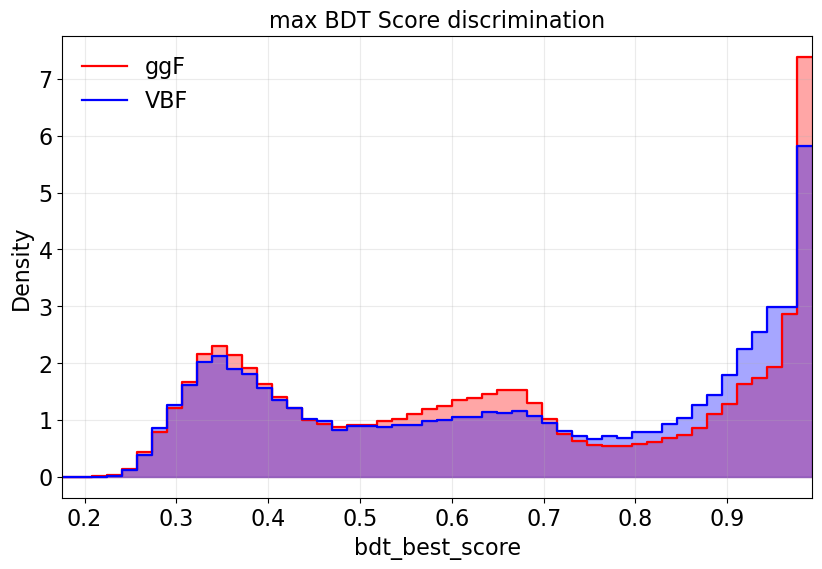

Variable name:  ('bdt_best_score', 0)
TMVA separation: 0.0121
JSD (bits):      0.0087
KS (weighted):   0.0623
AUC (weighted):  0.4848


In [11]:
plot_with_metrics(
    dfS=df_ggF_sm, dfB=df_vbf_sm,
    weight_col=('weight', 0),
    colorS='red', colorB='blue',
    labelS="ggF", labelB="VBF",
    
    bins=50, density=True,
    variable=("bdt_best_score", 0),
    xlabel="bdt_best_score",
    title="max BDT Score discrimination",
)


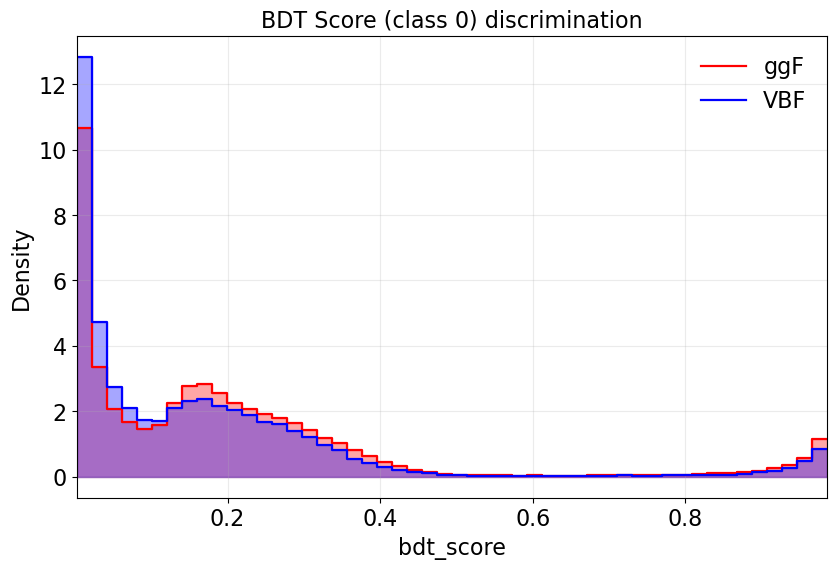

Variable name:  ('bdt_score', 0)
TMVA separation: 0.0119
JSD (bits):      0.0086
KS (weighted):   0.0996
AUC (weighted):  0.5503


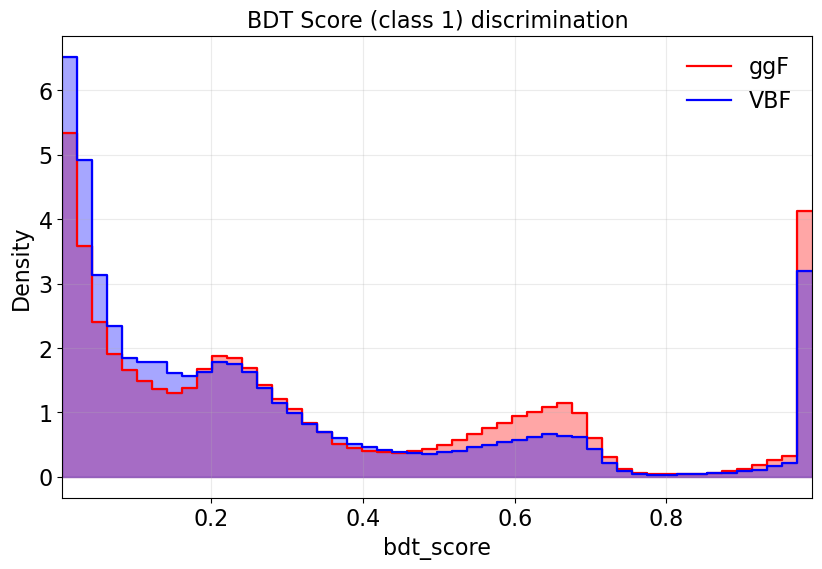

Variable name:  ('bdt_score', 1)
TMVA separation: 0.0159
JSD (bits):      0.0115
KS (weighted):   0.1009
AUC (weighted):  0.5621


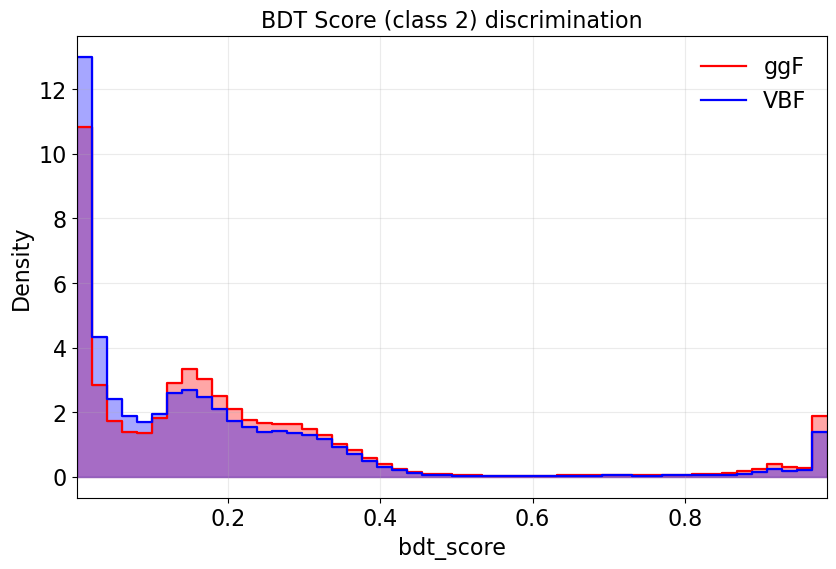

Variable name:  ('bdt_score', 2)
TMVA separation: 0.0134
JSD (bits):      0.0097
KS (weighted):   0.1051
AUC (weighted):  0.5482


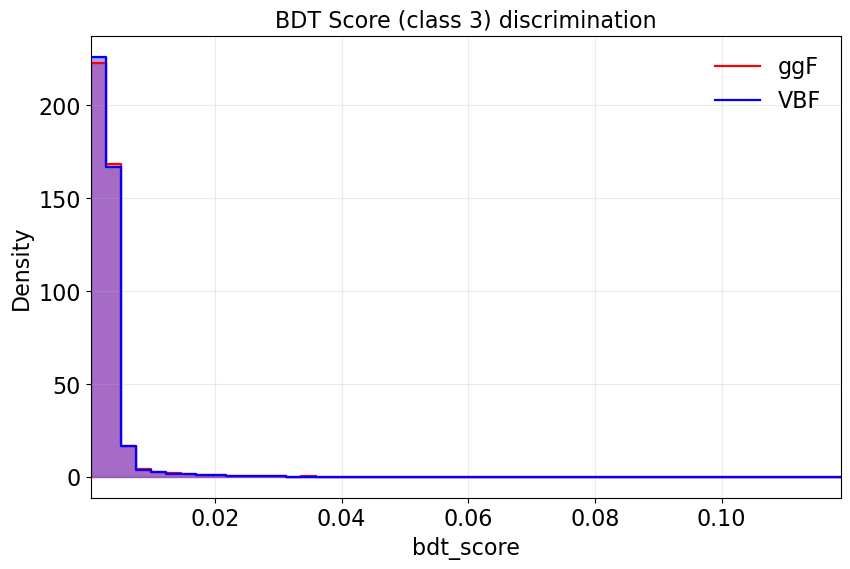

Variable name:  ('bdt_score', 3)
TMVA separation: 0.0004
JSD (bits):      0.0003
KS (weighted):   0.0706
AUC (weighted):  0.5206


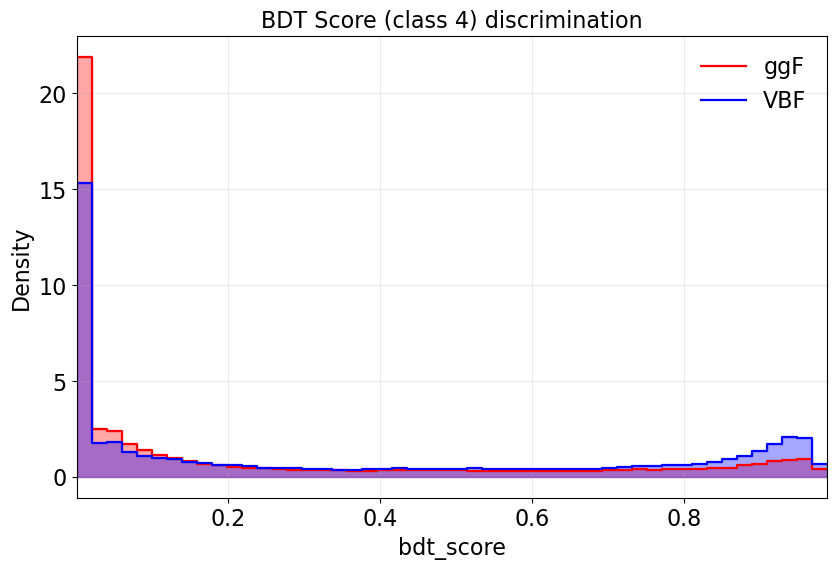

Variable name:  ('bdt_score', 4)
TMVA separation: 0.0389
JSD (bits):      0.0284
KS (weighted):   0.1766
AUC (weighted):  0.3966


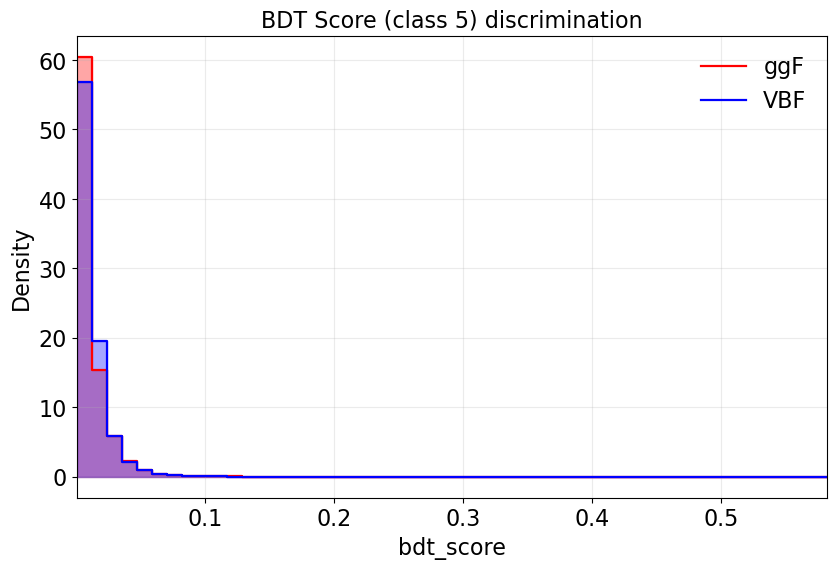

Variable name:  ('bdt_score', 5)
TMVA separation: 0.0038
JSD (bits):      0.0028
KS (weighted):   0.0972
AUC (weighted):  0.4547


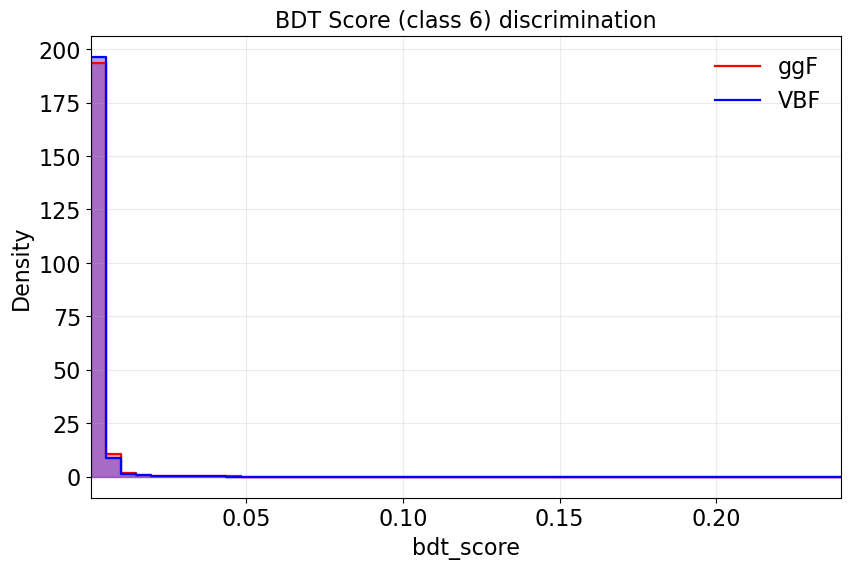

Variable name:  ('bdt_score', 6)
TMVA separation: 0.0009
JSD (bits):      0.0007
KS (weighted):   0.0551
AUC (weighted):  0.5214


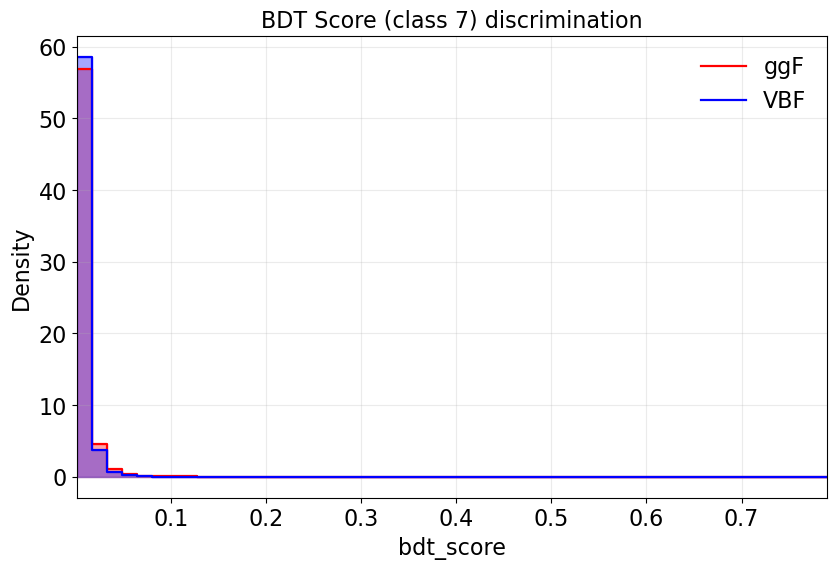

Variable name:  ('bdt_score', 7)
TMVA separation: 0.0031
JSD (bits):      0.0023
KS (weighted):   0.0393
AUC (weighted):  0.5014


In [12]:
for i in range(8):
    plot_with_metrics(
        dfS=df_ggF_sm, dfB=df_vbf_sm,
        weight_col=('weight', 0),
        colorS='red', colorB='blue',
        labelS="ggF", labelB="VBF",
        
        bins=50, density=True,
        variable=("bdt_score", i),
        xlabel="bdt_score",
        title="BDT Score (class {}) discrimination".format(i),
    )


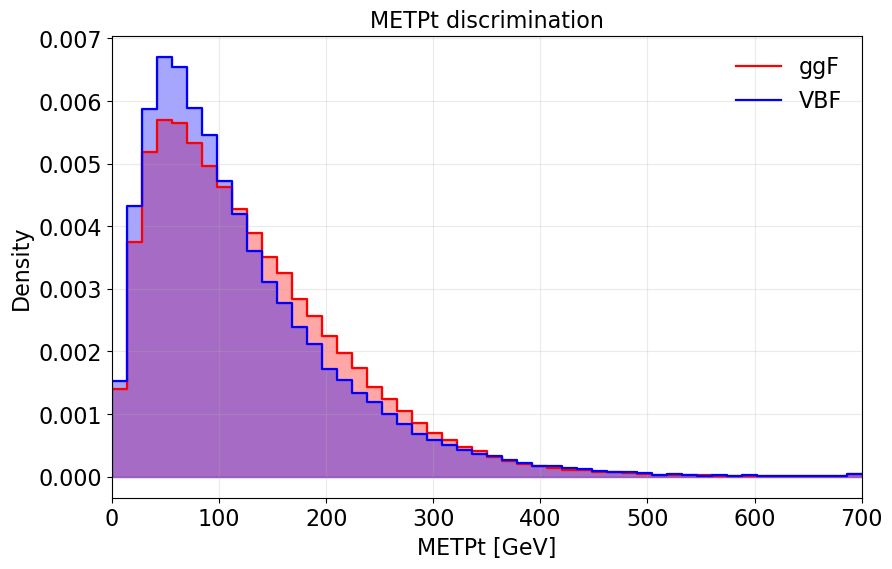

Variable name:  ('METPt', 0)
TMVA separation: 0.0054
JSD (bits):      0.0039
KS (weighted):   0.0642
AUC (weighted):  0.5356


In [13]:

plot_with_metrics(
    dfS=df_ggF_sm, dfB=df_vbf_sm,
    variable=('METPt', 0),
    weight_col=('weight', 0),
    colorS='red', colorB='blue',
    bins=50, xlim=(0, 700), density=True,
    labelS="ggF", labelB="VBF",
    xlabel="METPt [GeV]",
    title="METPt discrimination",
)


In [14]:
# Delta R and the tautau ak8 jets and VBF Jets
# 

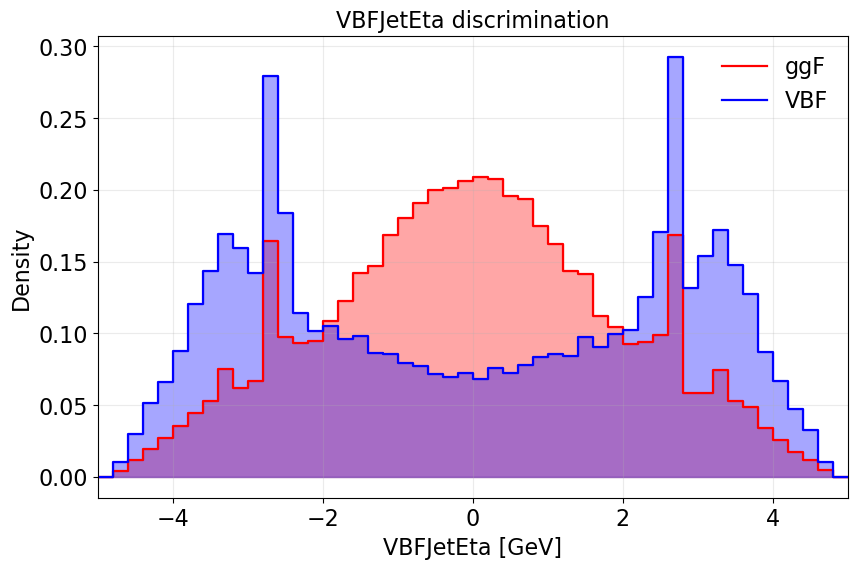

Variable name:  ('VBFJetEta', 0)
TMVA separation: 0.1272
JSD (bits):      0.0947
KS (weighted):   0.1659
AUC (weighted):  0.4984


In [15]:
# This can a VOI 
plot_with_metrics(
    dfS=df_ggF_sm, dfB=df_vbf_sm,
    weight_col=('weight', 0),
    colorS='red', colorB='blue',
    labelS="ggF", labelB="VBF",
    
    cuts=(-5, 5),
    bins=50, xlim=(-5, 5), density=True,
    variable=('VBFJetEta', 0),
    xlabel="VBFJetEta [GeV]",
    title="VBFJetEta discrimination",
)


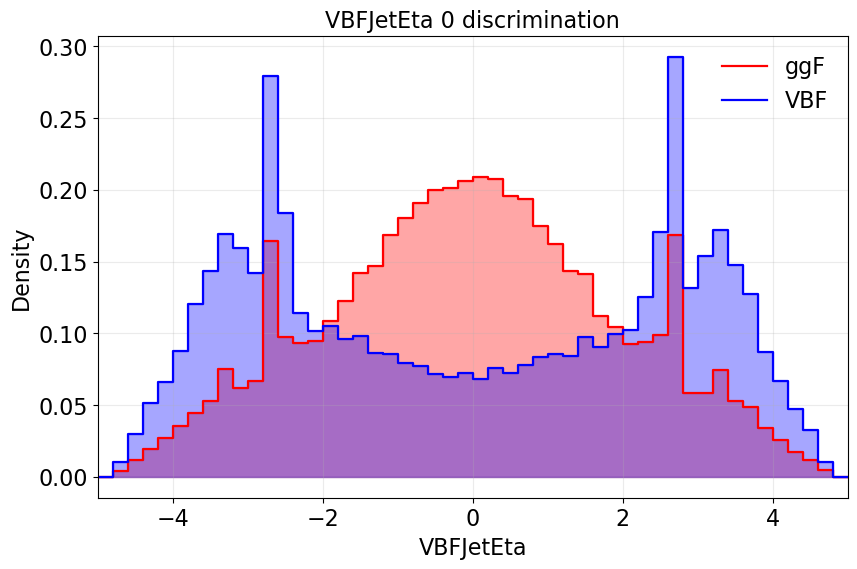

Variable name:  ('VBFJetEta', 0)
TMVA separation: 0.1272
JSD (bits):      0.0947
KS (weighted):   0.1659
AUC (weighted):  0.4984


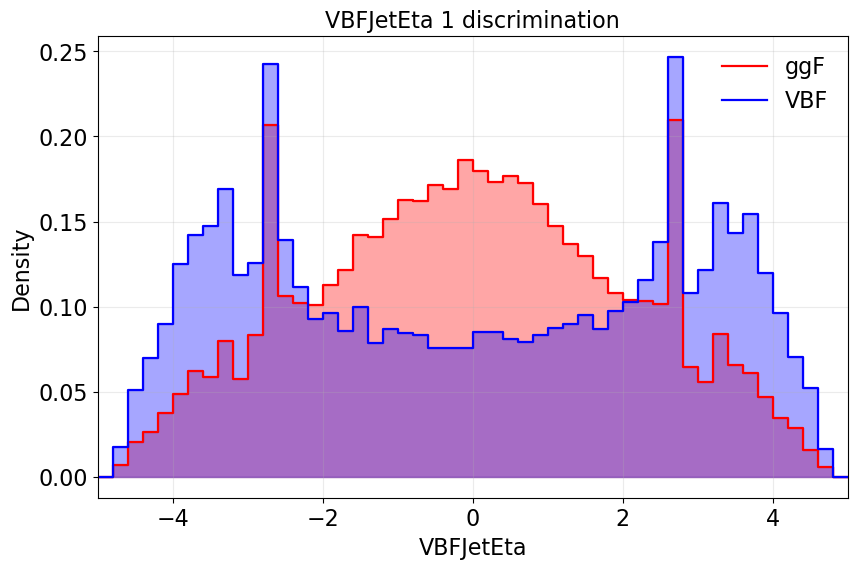

Variable name:  ('VBFJetEta', 1)
TMVA separation: 0.0887
JSD (bits):      0.0656
KS (weighted):   0.1342
AUC (weighted):  0.4974


In [16]:
plot_with_metrics(
    dfS=df_ggF_sm, dfB=df_vbf_sm,
    weight_col=('weight', 0),
    colorS='red', colorB='blue',
    labelS="ggF", labelB="VBF",
    
    cuts= (-5, 5),
    xlim=(-5, 5),
    bins=50, density=True,
    variable=("VBFJetEta", 0),
    xlabel="VBFJetEta",
    title="VBFJetEta 0 discrimination",
)

plot_with_metrics(
    dfS=df_ggF_sm, dfB=df_vbf_sm,
    weight_col=('weight', 0),
    colorS='red', colorB='blue',
    labelS="ggF", labelB="VBF",
    
    cuts= (-5, 5),
    xlim=(-5, 5),
    bins=50, density=True,
    variable=("VBFJetEta", 1),
    xlabel="VBFJetEta",
    title="VBFJetEta 1 discrimination",
)


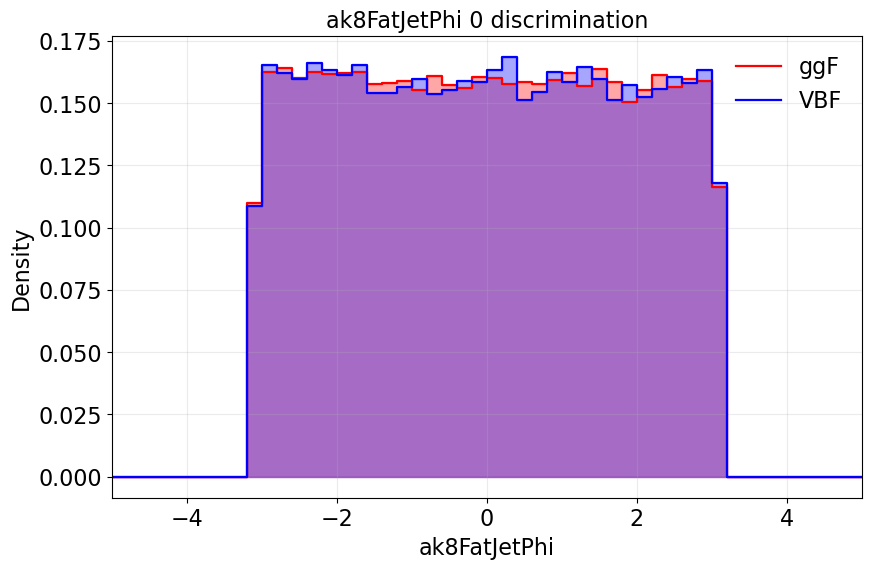

Variable name:  ('ak8FatJetPhi', 0)
TMVA separation: 0.0002
JSD (bits):      0.0001
KS (weighted):   0.0023
AUC (weighted):  0.4998


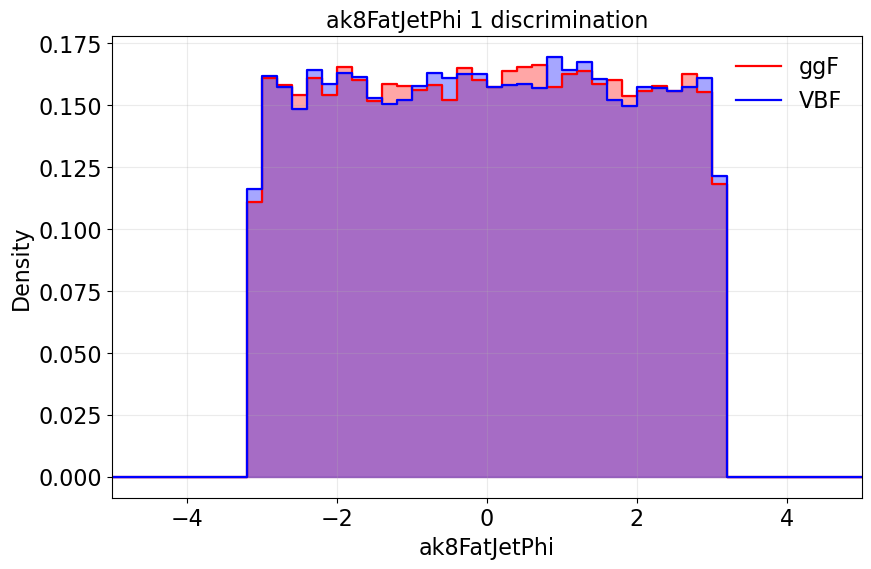

Variable name:  ('ak8FatJetPhi', 1)
TMVA separation: 0.0003
JSD (bits):      0.0002
KS (weighted):   0.0028
AUC (weighted):  0.5003


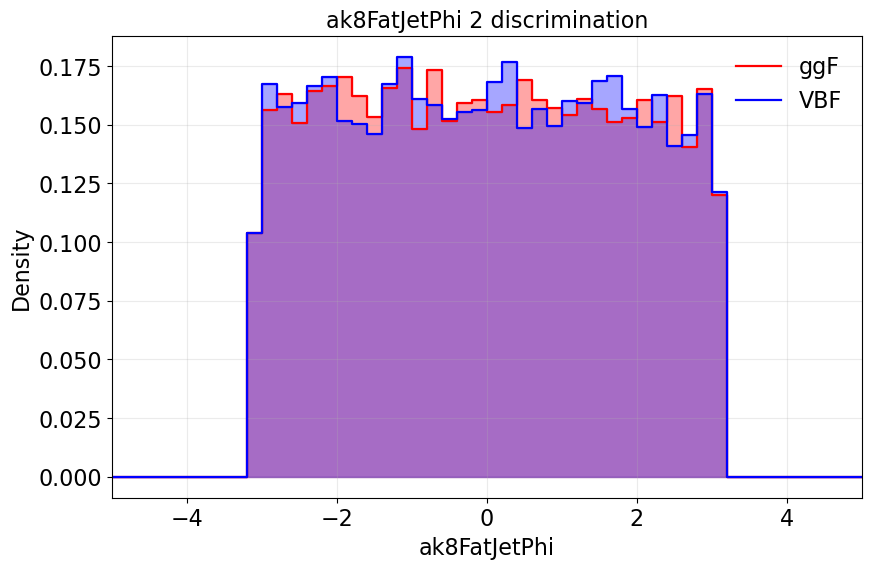

Variable name:  ('ak8FatJetPhi', 2)
TMVA separation: 0.0011
JSD (bits):      0.0008
KS (weighted):   0.0075
AUC (weighted):  0.4994


In [17]:
for i in range(10):
    var_name = "ak8FatJetPhi"
    try: 
        plot_with_metrics(
            dfS=df_ggF_sm, dfB=df_vbf_sm,
            weight_col=('weight', 0),
            colorS='red', colorB='blue',
            labelS="ggF", labelB="VBF",
            
            cuts= (-5, 5),
            xlim=(-5, 5),
            bins=50, density=True,
            variable=(var_name, i),
            xlabel=var_name,
            title=f"{var_name} {i} discrimination",
        )
    except: break


In [18]:
# Note: Most of the varibles are quite notorious to be used as a 
# good variable for S/B distinguishment just by based on cuts
#
# -> We must use combination of variables to make a good discriminator

def delta_phi(phi1, phi2):
    return ((phi1 - phi2 + np.pi) % (2*np.pi)) - np.pi

def P_vec4(pt, eta, phi, m):
    px = pt*np.cos(phi)
    py = pt*np.sin(phi)
    pz = pt*np.sinh(eta)
    E  = np.sqrt(px*px + py*py + pz*pz + m*m)
    return px,py,pz,E

# combine systems
def add4(a, b): 
    return tuple(ai + bi for ai, bi in zip(a, b))

def mass(px,py,pz,E):
    m2 = np.maximum(E*E - (px*px + py*py + pz*pz), 0.0)
    return np.sqrt(m2)

# helpers for boosts
def unit(vx, vy, vz, eps=1e-15):
    mag = np.sqrt(vx*vx + vy*vy + vz*vz)
    mag_safe = np.where(mag < eps, 1.0, mag)
    return vx/mag_safe, vy/mag_safe, vz/mag_safe, mag

def boost_to_rest(px,py,pz,E, Pparent):
    PX,PY,PZ,PE = Pparent
    ux,uy,uz,_ = unit(PX, PY, PZ)                                     # boost axis
    beta = np.sqrt(PX*PX + PY*PY + PZ*PZ) / np.maximum(PE, 1e-15)     # |β|
    small = beta < 1e-15
    gamma = 1.0 / np.sqrt(np.maximum(1.0 - beta*beta, 1e-30))
    # decompose along axis
    p_par = px*ux + py*uy + pz*uz
    px_perp = px - p_par*ux;  py_perp = py - p_par*uy;  pz_perp = pz - p_par*uz
    p_par_p = gamma*(p_par - beta*E)
    E_p     = gamma*(E    - beta*p_par)
    px_p = px_perp + p_par_p*ux
    py_p = py_perp + p_par_p*uy
    pz_p = pz_perp + p_par_p*uz
    # if β≈0, leave unchanged
    px_p = np.where(small, px, px_p)
    py_p = np.where(small, py, py_p)
    pz_p = np.where(small, pz, pz_p)
    E_p  = np.where(small, E,  E_p)
    return px_p, py_p, pz_p, E_p

# plane angle (ττ vs jj) in LAB and in ττ COM
def plane_angle(A1, A2, B1, B2, eps=1e-12):
    # A1..B2 are (N,3) arrays of spatial momenta
    nA = np.cross(A1, A2)
    nB = np.cross(B1, B2)
    nA_norm = np.linalg.norm(nA, axis=1)
    nB_norm = np.linalg.norm(nB, axis=1)
    cosang = np.einsum('ij,ij->i', nA, nB) / (np.maximum(nA_norm,eps)*np.maximum(nB_norm,eps))
    return np.arccos(np.clip(cosang, -1.0, 1.0))

def _mjj_ptjj(pt1,eta1,phi1,m1, pt2,eta2,phi2,m2):
    px1,py1,pz1,E1 = P_vec4(pt1,eta1,phi1,m1)
    px2,py2,pz2,E2 = P_vec4(pt2,eta2,phi2,m2)
    px,py,pz,E = px1+px2, py1+py2, pz1+pz2, E1+E2
    m2 = np.maximum(E*E - (px*px+py*py+pz*pz), 0.0)
    return np.sqrt(m2), np.sqrt(px*px+py*py)


/tmp/ipykernel_3731434/3199318492.py:12: RuntimeWarning: overflow encountered in sinh
  pz = pt*np.sinh(eta)
/tmp/ipykernel_3731434/3199318492.py:65: RuntimeWarning: invalid value encountered in subtract
  m2 = np.maximum(E*E - (px*px+py*py+pz*pz), 0.0)
/tmp/ipykernel_3731434/3199318492.py:12: RuntimeWarning: overflow encountered in sinh
  pz = pt*np.sinh(eta)
/tmp/ipykernel_3731434/3199318492.py:65: RuntimeWarning: invalid value encountered in subtract
  m2 = np.maximum(E*E - (px*px+py*py+pz*pz), 0.0)


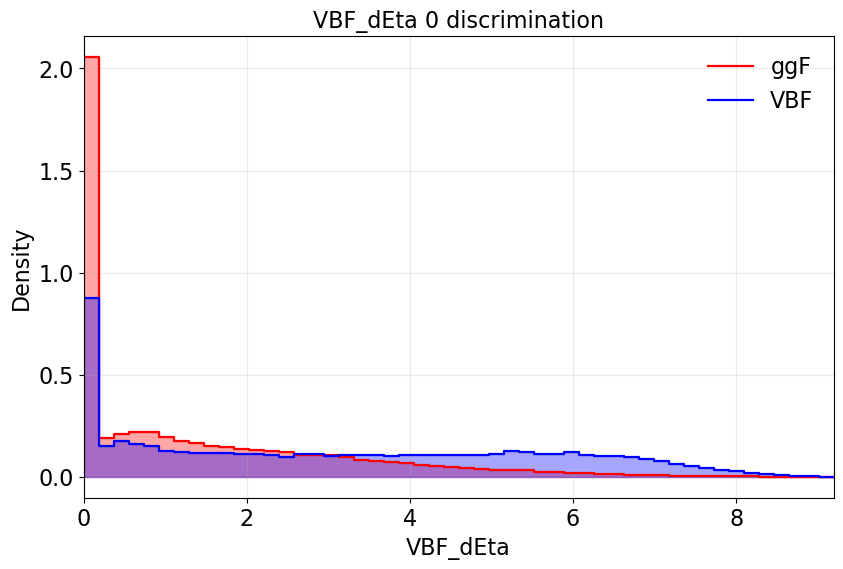

Variable name:  ('VBF_dEta', 0)
TMVA separation: 0.1485
JSD (bits):      0.1164
KS (weighted):   0.3125
AUC (weighted):  0.2901


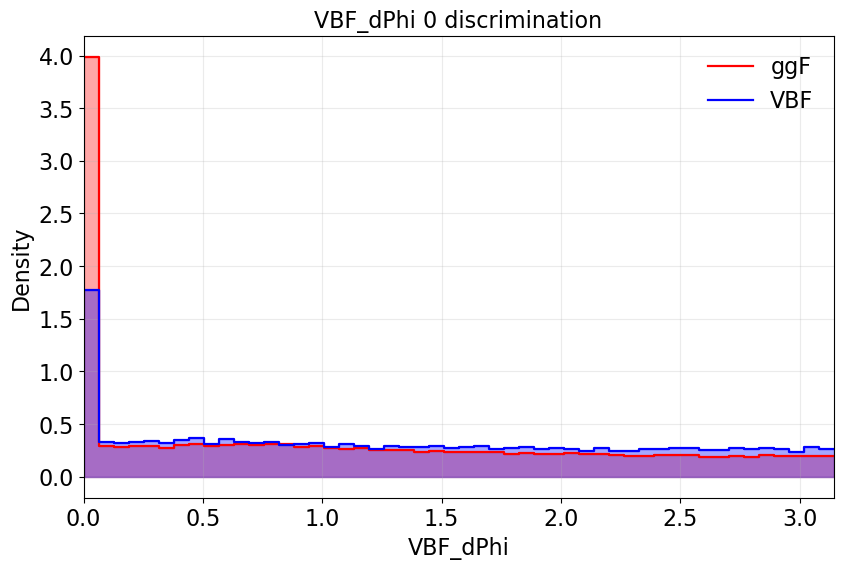

Variable name:  ('VBF_dPhi', 0)
TMVA separation: 0.0342
JSD (bits):      0.0252
KS (weighted):   0.1422
AUC (weighted):  0.4169


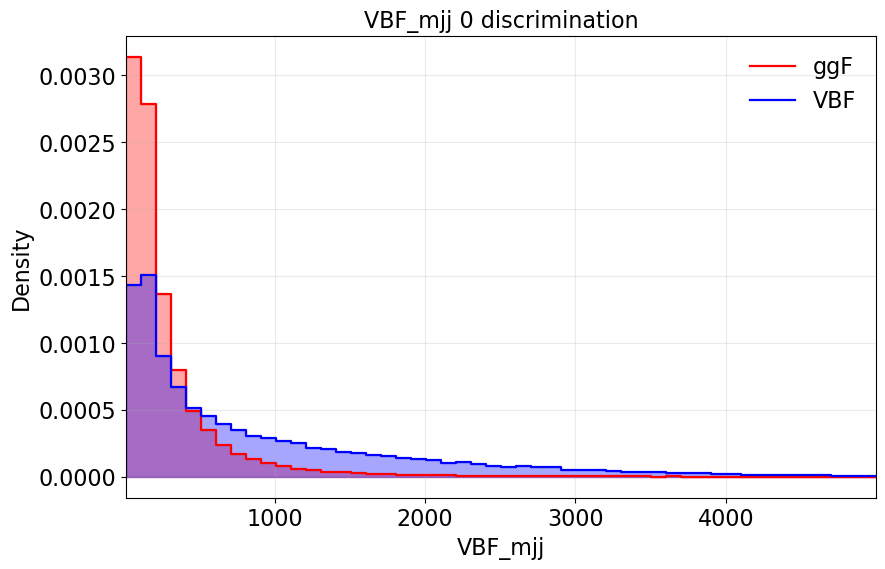

Variable name:  ('VBF_mjj', 0)
TMVA separation: 0.1772
JSD (bits):      0.1416
KS (weighted):   0.3581
AUC (weighted):  0.2767


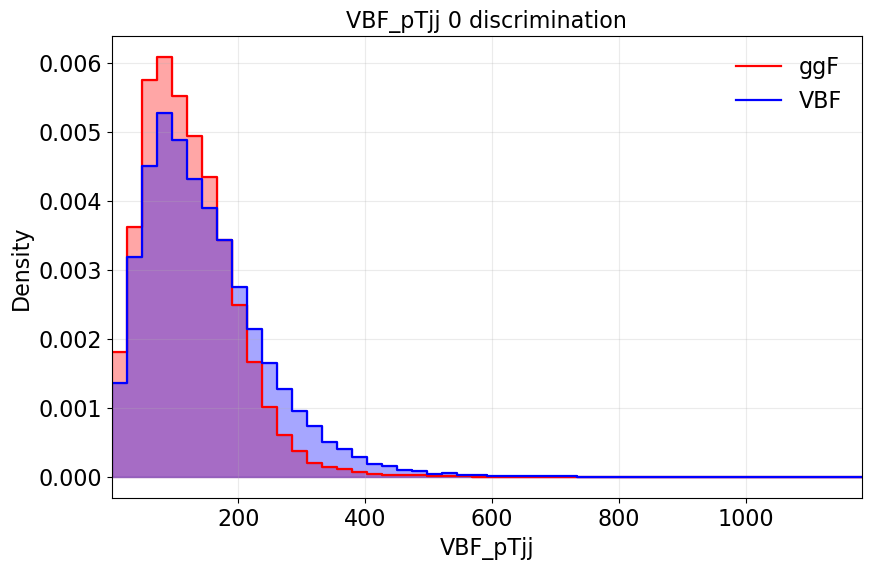

Variable name:  ('VBF_pTjj', 0)
TMVA separation: 0.0271
JSD (bits):      0.0204
KS (weighted):   0.1104
AUC (weighted):  0.4309


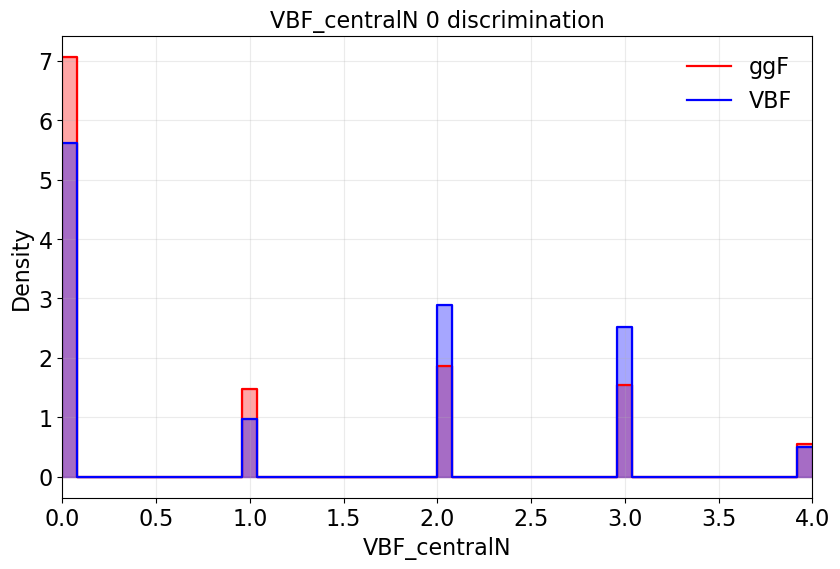

Variable name:  ('VBF_centralN', 0)
TMVA separation: 0.0291
JSD (bits):      0.0211
KS (weighted):   0.1560
AUC (weighted):  0.4301


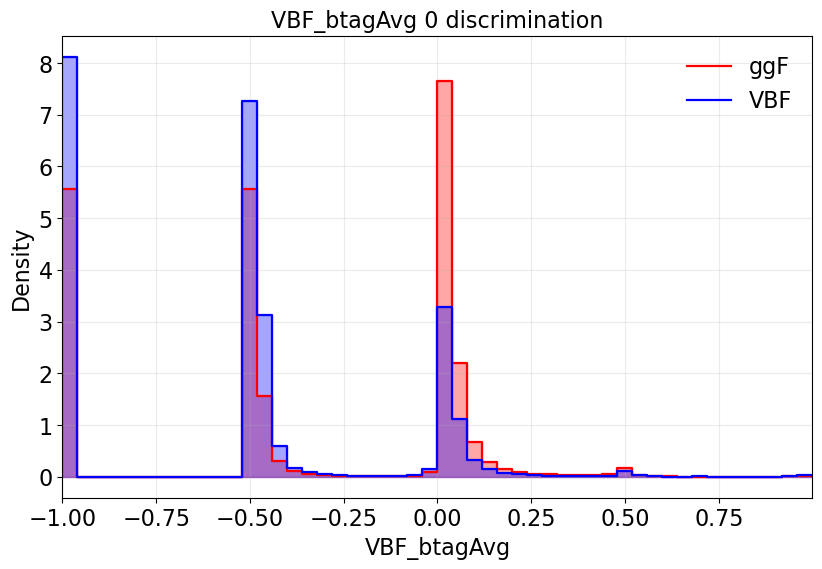

Variable name:  ('VBF_btagAvg', 0)
TMVA separation: 0.0752
JSD (bits):      0.0554
KS (weighted):   0.2518
AUC (weighted):  0.6140


In [19]:
# Add VBF features
def df_add_vbf_features(df):
    cols = df.columns
    
    eta0,eta1 = df[('VBFJetEta',0)].to_numpy(float), df[('VBFJetEta',1)].to_numpy(float)
    phi0,phi1 = df[('VBFJetPhi',0)].to_numpy(float), df[('VBFJetPhi',1)].to_numpy(float)
    pt0 ,pt1  = df[('VBFJetPt' ,0)].to_numpy(float), df[('VBFJetPt' ,1)].to_numpy(float)
    m0  ,m1   = df[('VBFJetMass',0)].to_numpy(float), df[('VBFJetMass',1)].to_numpy(float)
    
    df[('VBF_dEta',0)] = np.abs(eta0 - eta1)
    df[('VBF_dPhi',0)] = np.abs(delta_phi(phi0, phi1))
    mjj, ptjj = _mjj_ptjj(pt0,eta0,phi0,m0, pt1,eta1,phi1,m1)
    df[('VBF_mjj',0)]  = mjj  # mjj : It is the invariant mass of the dijet system
    df[('VBF_pTjj',0)] = ptjj # ptjj : It is the transverse momentum of the dijet system
    
    # central-jet count in gap (use up to 4 AK4 jets if available)
    if all(('ak4JetEta',i) in cols for i in range(2)) and all(('ak4JetPt',i) in cols for i in range(2)):
        etas = [df[('ak4JetEta',i)].to_numpy(float) for i in range(4) if ('ak4JetEta',i) in cols]
        pts  = [df[('ak4JetPt' ,i)].to_numpy(float) for i in range(4) if ('ak4JetPt' ,i) in cols]
        if etas and pts:
            etas = np.vstack(etas).T; pts = np.vstack(pts).T
            eta_min = np.minimum(eta0,eta1); eta_max = np.maximum(eta0,eta1)
            mask = (etas > eta_min[:,None]) & (etas < eta_max[:,None]) & (pts > 30.0)
            df[('VBF_centralN',0)] = mask.sum(axis=1).astype(float)
        if all(c in cols for c in [('VBFJetbtagPNetB',0),('VBFJetbtagPNetB',1)]):
            df[('VBF_btagAvg',0)] = 0.5*(df[('VBFJetbtagPNetB',0)].to_numpy(float)+df[('VBFJetbtagPNetB',1)].to_numpy(float))
    return df

df_ggF_sm = df_add_vbf_features(df_ggF_sm)
df_vbf_sm = df_add_vbf_features(df_vbf_sm)

var_name_list = ["VBF_dEta", "VBF_dPhi", "VBF_mjj", "VBF_pTjj", "VBF_centralN", "VBF_btagAvg"]
i = 0

for var_name in var_name_list:
    plot_with_metrics(
        dfS=df_ggF_sm, dfB=df_vbf_sm,
        weight_col=('weight', 0),
        colorS='red', colorB='blue',
        labelS="ggF", labelB="VBF",
        
        cuts= (-5, 5000),
        # xlim=(0, 4000),
        bins=50, density=True,
        variable=(var_name, i),
        xlabel=var_name,
        # logy=True,
        title=f"{var_name} {i} discrimination",
    )


In [23]:
def assign_ak4_roles(df):
    # Stack btag scores for the 4 AK4 jets
    btag = np.stack([df[("ak4JetbtagPNetB", i)].to_numpy(float) for i in range(4)], axis=1)
    sorted_idx = np.argsort(-btag, axis=1) # Sort jets by btag score descending

    b_idx = sorted_idx[:, :2]    # Top 2 -> b-jets,
    tau_idx = sorted_idx[:, 2:]  # next 2 -> tau-associated jets

    pt  = np.stack([df[("ak4JetPt", i)].to_numpy(float) for i in range(4)], axis=1)
    eta = np.stack([df[("ak4JetEta", i)].to_numpy(float) for i in range(4)], axis=1)
    phi = np.stack([df[("ak4JetPhi", i)].to_numpy(float) for i in range(4)], axis=1)
    mass = np.stack([df[("ak4JetMass", i)].to_numpy(float) for i in range(4)], axis=1)

    for j in range(2):
        # tau-associated jets
        df[("ak4TauJetPt", j)]   = np.take_along_axis(pt,  tau_idx[:, [j]], axis=1).flatten()
        df[("ak4TauJetEta", j)]  = np.take_along_axis(eta, tau_idx[:, [j]], axis=1).flatten()
        df[("ak4TauJetPhi", j)]  = np.take_along_axis(phi, tau_idx[:, [j]], axis=1).flatten()
        df[("ak4TauJetMass", j)] = np.take_along_axis(mass,tau_idx[:, [j]], axis=1).flatten()

        # b-associated jets
        df[("ak4BJetPt", j)]   = np.take_along_axis(pt,  b_idx[:, [j]], axis=1).flatten()
        df[("ak4BJetEta", j)]  = np.take_along_axis(eta, b_idx[:, [j]], axis=1).flatten()
        df[("ak4BJetPhi", j)]  = np.take_along_axis(phi, b_idx[:, [j]], axis=1).flatten()
        df[("ak4BJetMass", j)] = np.take_along_axis(mass,b_idx[:, [j]], axis=1).flatten()

    return df


df_ggF_sm = assign_ak4_roles(df_ggF_sm)
df_vbf_sm = assign_ak4_roles(df_vbf_sm)

In [50]:
# Test "taus ~ back-to-back in ττ COM" and correlation of τ plane with the VBF dijet plane.

def df_add_tau_vbf_angles(df, tau_src='Tau'):
    cols = df.columns
    N = len(df)
    
    def col(name, idx, default=0.0):
        key = (name, idx)
        if key in cols:
            return df[key].to_numpy(float)
        return np.full(N, default, float)
    
    assert tau_src in ["Tau", "BoostedTau", "ak4Jet", "VBFJet", "ak4TauJet"]

    # t_pt0, t_eta0, t_phi0, t_m0 = col(f'{tau_src}Pt',0), col(f'{tau_src}Eta',0), col(f'{tau_src}Phi',0), col(f'{tau_src}Mass',0,1.77686)
    # t_pt1, t_eta1, t_phi1, t_m1 = col(f'{tau_src}Pt',1), col(f'{tau_src}Eta',1), col(f'{tau_src}Phi',1), col(f'{tau_src}Mass',1,1.77686)
    
    m_def = 1.77686 if tau_src in ('Tau','BoostedTau') else 0.0
    t_pt0, t_eta0, t_phi0, t_m0 = (
        col(f'{tau_src}Pt',0),  col(f'{tau_src}Eta',0),  col(f'{tau_src}Phi',0),
        col(f'{tau_src}Mass',0, m_def)
    )
    t_pt1, t_eta1, t_phi1, t_m1 = (
        col(f'{tau_src}Pt',1),  col(f'{tau_src}Eta',1),  col(f'{tau_src}Phi',1),
        col(f'{tau_src}Mass',1, m_def)
    )

    # VBF dijet
    j_pt0, j_eta0, j_phi0, j_m0 = col('VBFJetPt',0), col('VBFJetEta',0), col('VBFJetPhi',0), col('VBFJetMass',0,0.0)
    j_pt1, j_eta1, j_phi1, j_m1 = col('VBFJetPt',1), col('VBFJetEta',1), col('VBFJetPhi',1), col('VBFJetMass',1,0.0)

    t0 = P_vec4(t_pt0, t_eta0, t_phi0, t_m0)
    t1 = P_vec4(t_pt1, t_eta1, t_phi1, t_m1)
    j0 = P_vec4(j_pt0, j_eta0, j_phi0, j_m0)
    j1 = P_vec4(j_pt1, j_eta1, j_phi1, j_m1)

    # combine systems
    tt = add4(t0, t1)
    jj = add4(j0, j1)

    df[('TauTau_dphi', 0)] = np.abs(delta_phi(t_phi0, t_phi1))
    df[('TauTau_deta', 0)] = np.abs(t_eta0 - t_eta1)
    df[('TauTau_mass', 0)] = mass(*tt)

    # Δφ between ττ and jj systems (transverse)
    tt_phi = np.arctan2(tt[1], tt[0])
    jj_phi = np.arctan2(jj[1], jj[0])
    df[('DeltaPhi_tt_jj', 0)] = np.abs(delta_phi(tt_phi, jj_phi))

    # cosθ* in ττ rest frame: angle between τ0* and ττ flight direction (helicity angle)
    ux,uy,uz,_ = unit(tt[0], tt[1], tt[2])
    t0_star = boost_to_rest(*t0, tt)
    p0star = np.sqrt(t0_star[0]**2 + t0_star[1]**2 + t0_star[2]**2) + 1e-15
    cos_theta_star = (t0_star[0]*ux + t0_star[1]*uy + t0_star[2]*uz) / p0star
    df[('TauTau_cosThetaStar', 0)] = np.clip(cos_theta_star, -1.0, 1.0)
    df[('TauTau_thetaStar', 0)] = np.arccos(cos_theta_star)

    a1_lab = np.column_stack((t0[0], t0[1], t0[2]))
    a2_lab = np.column_stack((t1[0], t1[1], t1[2]))
    b1_lab = np.column_stack((j0[0], j0[1], j0[2]))
    b2_lab = np.column_stack((j1[0], j1[1], j1[2]))
    df[('Angle_planes_lab', 0)] = plane_angle(a1_lab, a2_lab, b1_lab, b2_lab)

    t1_star = boost_to_rest(*t1, tt)
    j0_star = boost_to_rest(*j0, tt)
    j1_star = boost_to_rest(*j1, tt)
    
    a1_tt = np.column_stack((t0_star[0], t0_star[1], t0_star[2]))
    a2_tt = np.column_stack((t1_star[0], t1_star[1], t1_star[2]))
    b1_tt = np.column_stack((j0_star[0], j0_star[1], j0_star[2]))
    b2_tt = np.column_stack((j1_star[0], j1_star[1], j1_star[2]))
    df[('Angle_planes_ttRest', 0)] = plane_angle(a1_tt, a2_tt, b1_tt, b2_tt)
    
    def _angle3(A, B, eps=1e-15):
        dot = np.einsum('ij,ij->i', A, B)
        NA  = np.linalg.norm(A, axis=1)
        NB  = np.linalg.norm(B, axis=1)
        cosv = dot / np.maximum(NA*NB, eps)
        return np.arccos(np.clip(cosv, -1.0, 1.0)), np.clip(cosv, -1.0, 1.0)

    # build τ* and VBF* 3-vectors
    v_tau0 = a1_tt                      # τ0* 3-momentum
    v_tau1 = a2_tt                      # τ1* 3-momentum
    jj_star = add4(j0_star, j1_star)    # VBF* 4-vector
    v_jj   = np.column_stack((jj_star[0], jj_star[1], jj_star[2]))

    ang0, cos0 = _angle3(v_tau0, v_jj)
    ang1, cos1 = _angle3(v_tau1, v_jj)

    # store both angle (rad) and cosine
    df[('Angle_tau0_vs_VBF_tauTauRest', 0)] = ang0
    df[('Angle_tau1_vs_VBF_tauTauRest', 0)] = ang1
    df[('Cos_tau0_vs_VBF_tauTauRest', 0)]   = cos0
    df[('Cos_tau1_vs_VBF_tauTauRest', 0)]   = cos1

    # label-independent choice: the smaller of the two angles
    df[('Angle_tauMin_vs_VBF_tauTauRest', 0)] = np.minimum(ang0, ang1)

    # ττ acoplanarity (π - Δφ(τ1,τ2)) as a quick back-to-back check
    df[('TauTau_acoplanarity', 0)] = np.pi - df[('TauTau_dphi', 0)]

    return df


/tmp/ipykernel_3731434/3199318492.py:12: RuntimeWarning: overflow encountered in sinh
  pz = pt*np.sinh(eta)
/tmp/ipykernel_3731434/3199318492.py:21: RuntimeWarning: invalid value encountered in subtract
  m2 = np.maximum(E*E - (px*px + py*py + pz*pz), 0.0)
/tmp/ipykernel_3731434/3199318492.py:28: RuntimeWarning: invalid value encountered in divide
  return vx/mag_safe, vy/mag_safe, vz/mag_safe, mag
/tmp/ipykernel_3731434/3199318492.py:33: RuntimeWarning: invalid value encountered in divide
  beta = np.sqrt(PX*PX + PY*PY + PZ*PZ) / np.maximum(PE, 1e-15)     # |β|
/tmp/ipykernel_3731434/3199318492.py:58: RuntimeWarning: invalid value encountered in divide
  cosang = np.einsum('ij,ij->i', nA, nB) / (np.maximum(nA_norm,eps)*np.maximum(nB_norm,eps))
/tmp/ipykernel_3731434/3199318492.py:38: RuntimeWarning: invalid value encountered in subtract
  px_perp = px - p_par*ux;  py_perp = py - p_par*uy;  pz_perp = pz - p_par*uz
/tmp/ipykernel_3731434/3199318492.py:39: RuntimeWarning: invalid value 

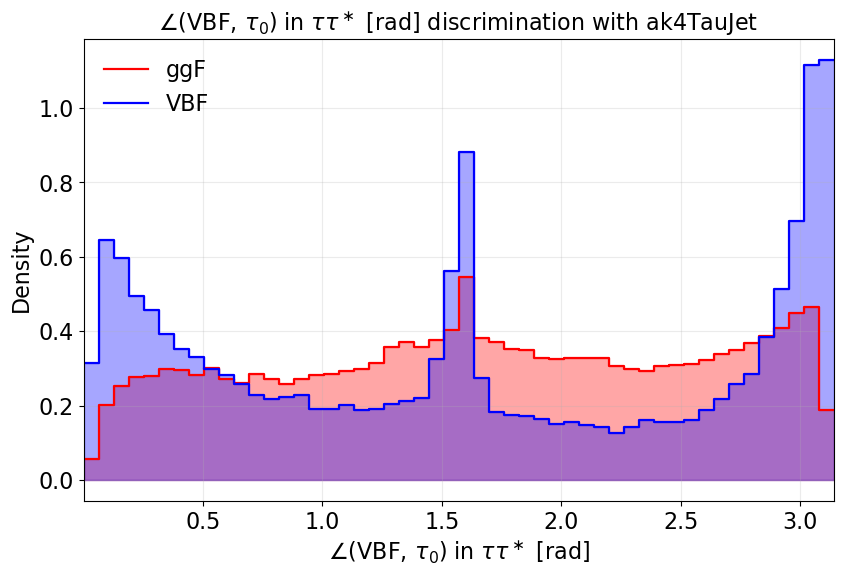

Variable name:  ('Angle_tau0_vs_VBF_tauTauRest', 0)
TMVA separation: 0.0929
JSD (bits):      0.0702
KS (weighted):   0.1225
AUC (weighted):  0.5085


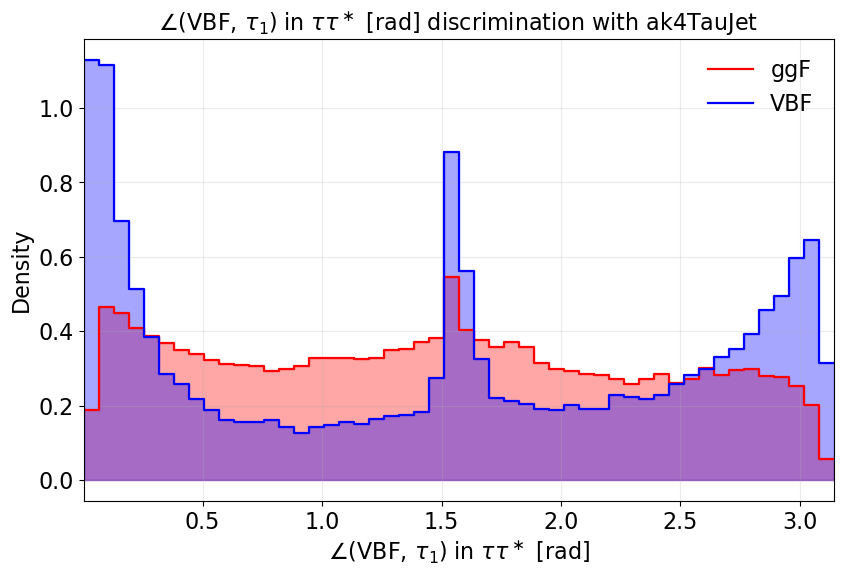

Variable name:  ('Angle_tau1_vs_VBF_tauTauRest', 0)
TMVA separation: 0.0929
JSD (bits):      0.0702
KS (weighted):   0.1225
AUC (weighted):  0.4915


In [56]:

# ["Tau", "BoostedTau", "ak4TauJet", "ak4Jet", "VBFJet"]
# --- Apply to both samples ---
tau_src = "ak4TauJet" 
df_ggF_sm = df_add_tau_vbf_angles(df_ggF_sm, tau_src=tau_src)
df_vbf_sm = df_add_tau_vbf_angles(df_vbf_sm, tau_src=tau_src)

# --- Quick discrimination plots (weighted) ---
vars_to_plot = [
    # 'TauTau_cosThetaStar',
    # 'TauTau_thetaStar',                    # NEW: θ* in radians
    'Angle_tau0_vs_VBF_tauTauRest',        # NEW: angle(VBF, τ0*) in ττ*
    'Angle_tau1_vs_VBF_tauTauRest',        # NEW: angle(VBF, τ1*) in ττ*
    # 'Angle_tauMin_vs_VBF_tauTauRest',      # NEW: min angle(VBF, τi*) in ττ*
#     'Angle_planes_ttRest',
#     'Angle_planes_lab',
#     'DeltaPhi_tt_jj',
#     'TauTau_acoplanarity',
]

xlabel_map = {
    'TauTau_cosThetaStar'           : r'$\cos\theta^{\ast}_{\tau\tau}$',
    'TauTau_thetaStar'              : r'$\theta^{\ast}_{\tau\tau}\;[\mathrm{rad}]$',
    'Angle_tau0_vs_VBF_tauTauRest'  : r'$\angle(\mathrm{VBF},\,\tau_0)\; \text{in}\ \tau\tau^\ast\ [\mathrm{rad}]$',
    'Angle_tau1_vs_VBF_tauTauRest'  : r'$\angle(\mathrm{VBF},\,\tau_1)\; \text{in}\ \tau\tau^\ast\ [\mathrm{rad}]$',
    'Angle_tauMin_vs_VBF_tauTauRest': r'$\min_i\,\angle(\mathrm{VBF},\,\tau_i)\; \text{in}\ \tau\tau^\ast\ [\mathrm{rad}]$',
    'Angle_planes_ttRest'           : r'$\angle(\Pi_{\tau\tau},\,\Pi_{jj})\;|\;\tau\tau^\ast\ [\mathrm{rad}]$',
    'Angle_planes_lab'              : r'$\angle(\Pi_{\tau\tau},\,\Pi_{jj})\;|\;\mathrm{lab}\ [\mathrm{rad}]$',
    'DeltaPhi_tt_jj'                : r'$\Delta\phi((\tau\tau),(jj))$',
    'TauTau_acoplanarity'           : r'$\varphi_{\mathrm{acop}}(\tau\tau)$',
}

for var in vars_to_plot:
    xlab = xlabel_map.get(var, var)
    plot_with_metrics(
        dfS=df_ggF_sm, dfB=df_vbf_sm,
        weight_col=('weight', 0),
        colorS='red', colorB='blue',
        labelS='ggF', labelB='VBF',
        bins=50, density=True,
        variable=(var, 0),
        xlabel=xlab,  # CHANGE: use LaTeX label
        title=f'{xlab} discrimination with {tau_src}'
    )
